# Experiment 5: KNN Classification

## Breast Cancer Diagnosis Prediction

**Objective:** Predict whether a tumor is benign or malignant based on medical measurements.

## Step 1: Import Required Libraries

In [1]:
print("Mithunjai.E\t\tExp-5\t\tRoll.no:24BAD071")
print()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

print("Libraries imported successfully!")

Mithunjai.E		Exp-5		Roll.no:24BAD071

Libraries imported successfully!


## Step 2: Load the Breast Cancer Dataset

In [2]:
# Load the dataset
df = pd.read_csv("breast-cancer.csv")

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (569, 32)

First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 3: Data Inspection & Preprocessing

In [5]:
# Check dataset info
print("Dataset Info:")
df.info()

print("\nDataset Description:")
print(df.describe())

print("\nColumn Names:")
print(df.columns)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se

In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Drop unnecessary columns
if 'id' in df.columns:
    df = df.drop('id', axis=1)
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)

print("\nData cleaned!")

Missing Values:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Data cleaned!


Target Variable Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


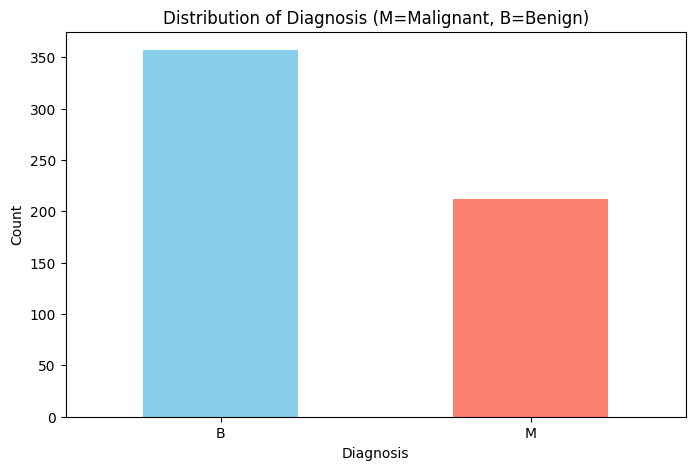

In [5]:
# Check target variable distribution
print("Target Variable Distribution:")
print(df['diagnosis'].value_counts())

# Visualize target distribution
plt.figure(figsize=(8,5))
df['diagnosis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Diagnosis (M=Malignant, B=Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Step 4: Encode Target Labels

In [6]:
# Encode target variable (M=Malignant=1, B=Benign=0)
label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])

print("Label Encoding:")
print("M (Malignant) -> 1")
print("B (Benign) -> 0")

print("\nEncoded target variable:")
print(df['diagnosis'].value_counts())

Label Encoding:
M (Malignant) -> 1
B (Benign) -> 0

Encoded target variable:
diagnosis
0    357
1    212
Name: count, dtype: int64


## Step 5: Select Features and Target

In [7]:
# Select required features
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']

X = df[features]
y = df['diagnosis']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nSelected Features:")
display(X.head())

Features shape: (569, 5)
Target shape: (569,)

Selected Features:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean
0,17.99,10.38,122.80,1001.0,0.11840
1,20.57,17.77,132.90,1326.0,0.08474
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
4,20.29,14.34,135.10,1297.0,0.10030


## Step 6: Feature Scaling (Important for KNN)

In [8]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully!")
print(f"Scaled features shape: {X_scaled.shape}")

# Convert to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("\nScaled Features (first 5 rows):")
display(X_scaled_df.head())

Features scaled successfully!
Scaled features shape: (569, 5)

Scaled Features (first 5 rows):


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean
0,1.097064,-2.073335,1.269934,0.984375,1.568466
1,1.829821,-0.353632,1.685955,1.908708,-0.826962
2,1.579888,0.456187,1.566503,1.558884,0.942210
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553
4,1.750297,-1.151816,1.776573,1.826229,0.280372


## Step 7: Train-Test Split

In [9]:
# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTesting set distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 455
Testing set size: 114

Training set distribution:
diagnosis
0    286
1    169
Name: count, dtype: int64

Testing set distribution:
diagnosis
0    71
1    43
Name: count, dtype: int64


## Step 8: Train KNN Classifier (K=5)

In [10]:
# Initialize and train KNN classifier with K=5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("KNN model trained successfully with K=5!")

KNN model trained successfully with K=5!


## Step 9: Make Predictions

In [11]:
# Predict on test set
y_pred = knn_model.predict(X_test)

print("Predictions made successfully!")
print(f"\nFirst 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

Predictions made successfully!

First 10 predictions: [0 1 1 0 0 1 1 0 0 0]
First 10 actual values: [0 1 1 0 0 1 1 1 0 0]


## Step 10: Evaluate Model Performance

In [12]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance Metrics (K=5):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

Model Performance Metrics (K=5):
Accuracy: 0.9298
Precision: 0.9070
Recall: 0.9070
F1 Score: 0.9070

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        71
   Malignant       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



## Step 11: Identify Misclassified Cases

In [13]:
# Find misclassified samples
misclassified_idx = np.where(y_test.values != y_pred)[0]

print(f"Number of misclassified cases: {len(misclassified_idx)}")
print(f"Total test samples: {len(y_test)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(y_test)*100:.2f}%")

if len(misclassified_idx) > 0:
    print("\nFirst 5 misclassified cases:")
    for i in misclassified_idx[:5]:
        print(f"Index {i}: Actual={y_test.values[i]}, Predicted={y_pred[i]}")

Number of misclassified cases: 8
Total test samples: 114
Misclassification rate: 7.02%

First 5 misclassified cases:
Index 7: Actual=1, Predicted=0
Index 20: Actual=1, Predicted=0
Index 25: Actual=0, Predicted=1
Index 39: Actual=0, Predicted=1
Index 52: Actual=0, Predicted=1


## Step 12: Experiment with Different K Values

In [14]:
# Test different K values
k_values = range(1, 31)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    accuracy_scores.append(acc)

print("Testing different K values completed!")

# Find best K
best_k = k_values[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)

print(f"\nBest K value: {best_k}")
print(f"Best accuracy: {best_accuracy:.4f}")

Testing different K values completed!

Best K value: 28
Best accuracy: 0.9737


## Visualization 1: Confusion Matrix

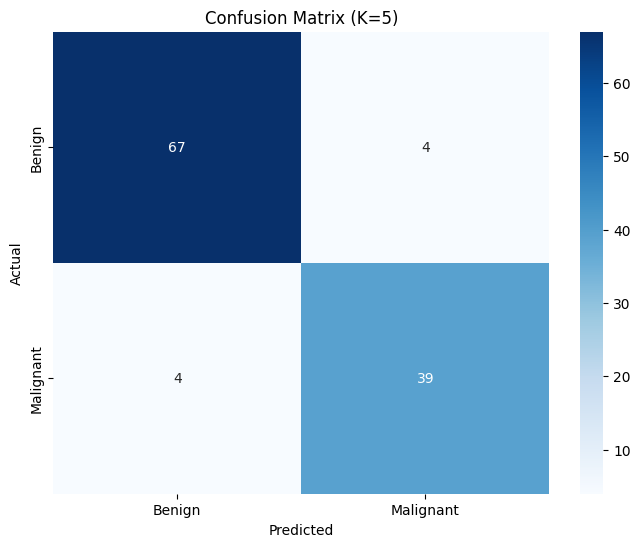


True Negatives: 67
False Positives: 4
False Negatives: 4
True Positives: 39


In [15]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (K=5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Visualization 2: Accuracy vs K Plot

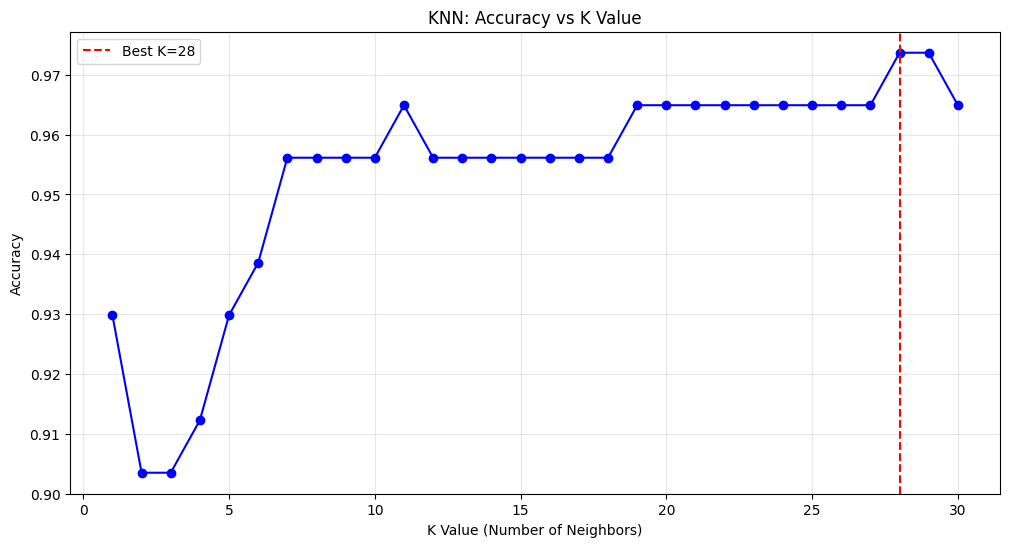

Optimal K value: 28 with accuracy: 0.9737


In [16]:
# Plot accuracy vs K
plt.figure(figsize=(12, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-', color='blue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Optimal K value: {best_k} with accuracy: {best_accuracy:.4f}")

## Visualization 3: Decision Boundary (Using Two Features)

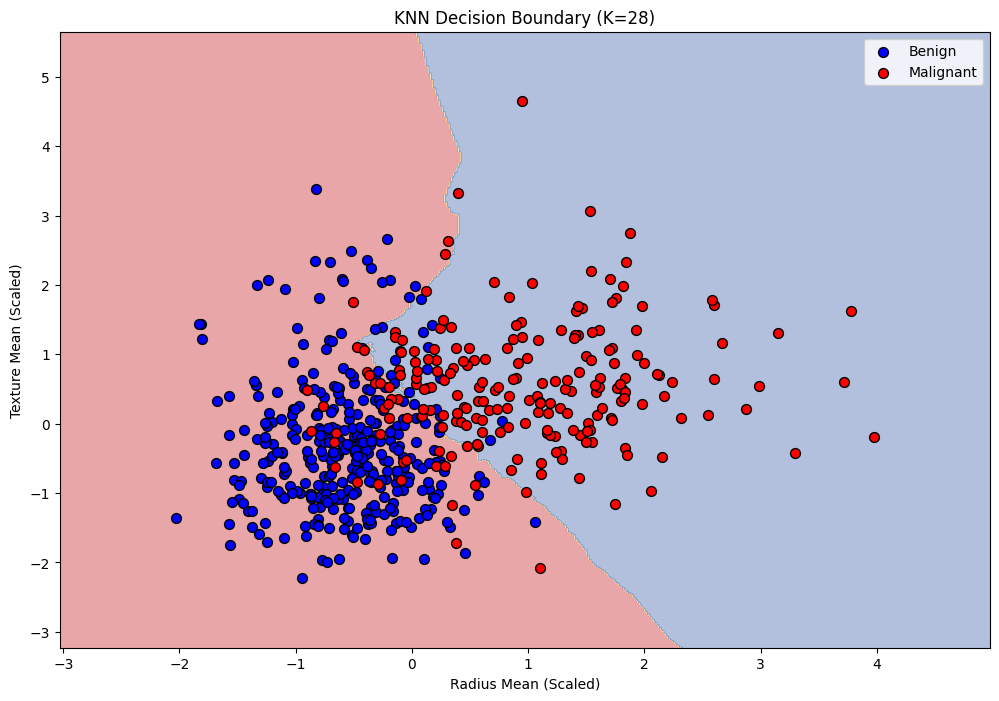

Decision boundary visualization completed!


In [17]:
# Train KNN with only 2 features for visualization
X_2d = df[['radius_mean', 'texture_mean']].values
X_2d_scaled = StandardScaler().fit_transform(X_2d)

# Split data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d_scaled, y, test_size=0.2, random_state=42
)

# Train model
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d, y_train_2d)

# Create mesh grid
h = 0.02  # step size
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on mesh
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
plt.scatter(X_2d_scaled[y==0, 0], X_2d_scaled[y==0, 1], 
           c='blue', label='Benign', edgecolors='k', s=50)
plt.scatter(X_2d_scaled[y==1, 0], X_2d_scaled[y==1, 1], 
           c='red', label='Malignant', edgecolors='k', s=50)
plt.xlabel('Radius Mean (Scaled)')
plt.ylabel('Texture Mean (Scaled)')
plt.title(f'KNN Decision Boundary (K={best_k})')
plt.legend()
plt.show()

print("Decision boundary visualization completed!")

## Step 13: Train Model with Best K

In [ ]:
# Train final model with best K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

# Predictions
final_pred = final_knn.predict(X_test)

# Final evaluation
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)

print(f"Final Model Performance (K={best_k}):")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall: {final_recall:.4f}")
print(f"F1 Score: {final_f1:.4f}")

print("KNN Classification Experiment Completed!")

Final Model Performance (K=28):
Accuracy: 0.9737
Precision: 0.9762
Recall: 0.9535
F1 Score: 0.9647

KNN Classification Experiment Completed!


## Summary - KNN Classification

### Key Findings:
1. KNN classifier successfully predicts breast cancer diagnosis
2. Feature scaling is critical for KNN performance
3. Optimal K value was determined through experimentation
4. Model shows good performance on test data
5. Decision boundary visualization helps understand the classification

---
---

# SCENARIO 2: Decision Tree Classifier

## Loan Application Prediction

**Objective:** Predict whether a loan application should be approved or rejected based on applicant information.

## Step 1: Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

print("Libraries imported successfully for Decision Tree!")

## Step 2: Load the Loan Prediction Dataset

In [ ]:
# Load the dataset
loan_df = pd.read_csv("loan_prediction.csv")

print("Loan dataset loaded successfully!")
print(f"Dataset shape: {loan_df.shape}")
print("\nFirst 5 rows:")
display(loan_df.head())

## Step 3: Data Inspection

In [ ]:
# Check dataset info
print("Dataset Info:")
loan_df.info()

print("\nDataset Description:")
display(loan_df.describe())

print("\nColumn Names:")
print(loan_df.columns.tolist())

In [ ]:
# Check for missing values
print("Missing Values:")
print(loan_df.isnull().sum())

print("\nMissing Value Percentage:")
missing_pct = (loan_df.isnull().sum() / len(loan_df)) * 100
print(missing_pct[missing_pct > 0])

In [ ]:
# Check target variable distribution
print("Loan Status Distribution:")
print(loan_df['Loan_Status'].value_counts())

# Visualize target distribution
plt.figure(figsize=(8,5))
loan_df['Loan_Status'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Loan Status (Y=Approved, N=Rejected)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Step 4: Data Preprocessing - Handle Missing Values

In [ ]:
# Create a copy for preprocessing
loan_data = loan_df.copy()

# Drop Loan_ID as it's not useful for prediction
if 'Loan_ID' in loan_data.columns:
    loan_data = loan_data.drop('Loan_ID', axis=1)

# Handle missing values for categorical columns (fill with mode)
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']

for col in categorical_cols:
    if col in loan_data.columns and loan_data[col].isnull().any():
        loan_data[col].fillna(loan_data[col].mode()[0], inplace=True)

# Handle missing values for numerical columns (fill with median)
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']

for col in numerical_cols:
    if col in loan_data.columns and loan_data[col].isnull().any():
        loan_data[col].fillna(loan_data[col].median(), inplace=True)

print("Missing values handled!")
print("\nMissing values after preprocessing:")
print(loan_data.isnull().sum())

## Step 5: Encode Categorical Variables

In [ ]:
# Encode target variable (Y=Approved=1, N=Rejected=0)
label_encoder_target = LabelEncoder()
loan_data['Loan_Status'] = label_encoder_target.fit_transform(loan_data['Loan_Status'])

print("Target Variable Encoding:")
print("Y (Approved) -> 1")
print("N (Rejected) -> 0")

# Encode other categorical features
categorical_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']

label_encoders = {}
for col in categorical_features:
    if col in loan_data.columns:
        le = LabelEncoder()
        loan_data[col] = le.fit_transform(loan_data[col].astype(str))
        label_encoders[col] = le

print("\nCategorical features encoded successfully!")
print("\nEncoded data sample:")
display(loan_data.head())

## Step 6: Select Features and Target

In [ ]:
# Select required features
features = ['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Education', 'Property_Area']

X_loan = loan_data[features]
y_loan = loan_data['Loan_Status']

print(f"Features shape: {X_loan.shape}")
print(f"Target shape: {y_loan.shape}")

print("\nSelected Features:")
display(X_loan.head())

print("\nFeature Statistics:")
display(X_loan.describe())

## Step 7: Train-Test Split

In [ ]:
# Split dataset (80% train, 20% test)
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(
    X_loan, y_loan, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_loan.shape[0]}")
print(f"Testing set size: {X_test_loan.shape[0]}")
print(f"\nTraining set distribution:")
print(pd.Series(y_train_loan).value_counts())
print(f"\nTesting set distribution:")
print(pd.Series(y_test_loan).value_counts())

## Step 8: Train Decision Tree Classifier (Default)

In [ ]:
# Initialize and train Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_loan, y_train_loan)

print("Decision Tree model trained successfully!")
print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

## Step 9: Make Predictions

In [ ]:
# Predict on test set
y_pred_loan = dt_model.predict(X_test_loan)

print("Predictions made successfully!")
print(f"\nFirst 10 predictions: {y_pred_loan[:10]}")
print(f"First 10 actual values: {y_test_loan.values[:10]}")

## Step 10: Evaluate Model Performance

In [ ]:
# Calculate evaluation metrics
accuracy_loan = accuracy_score(y_test_loan, y_pred_loan)
precision_loan = precision_score(y_test_loan, y_pred_loan)
recall_loan = recall_score(y_test_loan, y_pred_loan)
f1_loan = f1_score(y_test_loan, y_pred_loan)

print("Model Performance Metrics (Default Tree):")
print(f"Accuracy: {accuracy_loan:.4f}")
print(f"Precision: {precision_loan:.4f}")
print(f"Recall: {recall_loan:.4f}")
print(f"F1 Score: {f1_loan:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_loan, y_pred_loan, target_names=['Rejected', 'Approved']))

## Step 11: Analyze Feature Importance

In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance in Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## Step 12: Experiment with Tree Depth / Pruning

In [ ]:
# Test different max_depth values
depths = range(1, 16)
train_accuracies = []
test_accuracies = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train_loan, y_train_loan)
    
    train_pred = dt_temp.predict(X_train_loan)
    test_pred = dt_temp.predict(X_test_loan)
    
    train_acc = accuracy_score(y_train_loan, train_pred)
    test_acc = accuracy_score(y_test_loan, test_pred)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

print("Tree depth experimentation completed!")

# Find best depth
best_depth = depths[np.argmax(test_accuracies)]
best_test_accuracy = max(test_accuracies)

print(f"\nBest tree depth: {best_depth}")
print(f"Best test accuracy: {best_test_accuracy:.4f}")

## Step 13: Detect Overfitting Behavior

In [ ]:
# Plot training vs testing accuracy
plt.figure(figsize=(12, 6))
plt.plot(depths, train_accuracies, marker='o', label='Training Accuracy', color='blue')
plt.plot(depths, test_accuracies, marker='o', label='Testing Accuracy', color='red')
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth={best_depth}')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy (Overfitting Detection)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate overfitting gap
for i, depth in enumerate(depths):
    gap = train_accuracies[i] - test_accuracies[i]
    if depth == best_depth or depth == max(depths) or depth == 1:
        print(f"Depth {depth}: Train={train_accuracies[i]:.4f}, Test={test_accuracies[i]:.4f}, Gap={gap:.4f}")

## Step 14: Compare Shallow vs Deep Trees

In [ ]:
# Train shallow tree (max_depth=3)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train_loan, y_train_loan)
y_pred_shallow = dt_shallow.predict(X_test_loan)

# Train deep tree (max_depth=15)
dt_deep = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_deep.fit(X_train_loan, y_train_loan)
y_pred_deep = dt_deep.predict(X_test_loan)

# Compare performance
print("Shallow Tree (max_depth=3):")
print(f"  Accuracy: {accuracy_score(y_test_loan, y_pred_shallow):.4f}")
print(f"  Tree Depth: {dt_shallow.get_depth()}")
print(f"  Number of Leaves: {dt_shallow.get_n_leaves()}")

print("\nDeep Tree (max_depth=15):")
print(f"  Accuracy: {accuracy_score(y_test_loan, y_pred_deep):.4f}")
print(f"  Tree Depth: {dt_deep.get_depth()}")
print(f"  Number of Leaves: {dt_deep.get_n_leaves()}")

print(f"\nOptimal Tree (max_depth={best_depth}):")
dt_optimal = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_optimal.fit(X_train_loan, y_train_loan)
y_pred_optimal = dt_optimal.predict(X_test_loan)
print(f"  Accuracy: {accuracy_score(y_test_loan, y_pred_optimal):.4f}")
print(f"  Tree Depth: {dt_optimal.get_depth()}")
print(f"  Number of Leaves: {dt_optimal.get_n_leaves()}")

## Visualization 1: Confusion Matrix

In [ ]:
# Create confusion matrix for optimal model
cm_loan = confusion_matrix(y_test_loan, y_pred_optimal)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_loan, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Rejected', 'Approved'], 
            yticklabels=['Rejected', 'Approved'])
plt.title(f'Confusion Matrix (Optimal Depth={best_depth})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nTrue Negatives (Correctly Rejected): {cm_loan[0,0]}")
print(f"False Positives (Incorrectly Approved): {cm_loan[0,1]}")
print(f"False Negatives (Incorrectly Rejected): {cm_loan[1,0]}")
print(f"True Positives (Correctly Approved): {cm_loan[1,1]}")

## Visualization 2: Tree Structure Plot (Shallow Tree)

In [ ]:
# Visualize the shallow tree structure
plt.figure(figsize=(20, 10))
plot_tree(dt_shallow, 
          feature_names=features, 
          class_names=['Rejected', 'Approved'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (Shallow Tree - Depth=3)')
plt.show()

print("Shallow tree structure visualized!")

## Visualization 3: Tree Structure Plot (Optimal Tree)

In [ ]:
# Visualize the optimal tree structure
plt.figure(figsize=(25, 12))
plot_tree(dt_optimal, 
          feature_names=features, 
          class_names=['Rejected', 'Approved'],
          filled=True, 
          rounded=True,
          fontsize=8)
plt.title(f'Decision Tree Structure (Optimal Tree - Depth={best_depth})')
plt.show()

print("Optimal tree structure visualized!")

## Visualization 4: Pruning Comparison

In [ ]:
# Compare different pruning strategies
min_samples_splits = [2, 5, 10, 20, 50]
pruning_accuracies = []

for min_split in min_samples_splits:
    dt_pruned = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_split=min_split,
        random_state=42
    )
    dt_pruned.fit(X_train_loan, y_train_loan)
    y_pred_pruned = dt_pruned.predict(X_test_loan)
    acc = accuracy_score(y_test_loan, y_pred_pruned)
    pruning_accuracies.append(acc)

# Plot pruning results
plt.figure(figsize=(10, 6))
plt.plot(min_samples_splits, pruning_accuracies, marker='o', color='purple')
plt.xlabel('Min Samples Split')
plt.ylabel('Accuracy')
plt.title('Effect of Pruning (min_samples_split) on Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

print("Pruning comparison:")
for i, min_split in enumerate(min_samples_splits):
    print(f"min_samples_split={min_split}: Accuracy={pruning_accuracies[i]:.4f}")

## Step 15: Final Model Evaluation

In [ ]:
# Train final model with optimal parameters
final_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=5,
    random_state=42
)
final_dt.fit(X_train_loan, y_train_loan)

# Final predictions
final_pred_loan = final_dt.predict(X_test_loan)

# Final evaluation
final_accuracy_loan = accuracy_score(y_test_loan, final_pred_loan)
final_precision_loan = precision_score(y_test_loan, final_pred_loan)
final_recall_loan = recall_score(y_test_loan, final_pred_loan)
final_f1_loan = f1_score(y_test_loan, final_pred_loan)

print(f"Final Model Performance (Depth={best_depth}, min_samples_split=5):")
print(f"Accuracy: {final_accuracy_loan:.4f}")
print(f"Precision: {final_precision_loan:.4f}")
print(f"Recall: {final_recall_loan:.4f}")
print(f"F1 Score: {final_f1_loan:.4f}")

print("Decision Tree Classification Experiment Completed!")
